## 🍎 Fresh vs Rotten Fruit Classification: A Robust Transfer Learning Approach

### Author: Göktan İren

### Description: In this notebook, we tackle the "Fresh vs Rotten" classification problem using Transfer Learning with EfficientNetV2B0. 

### Key Features:

1. Robust Data Pipeline: Custom cleaning to handle corrupt images that often break TensorFlow pipelines.

2. tf.data API: Optimized data loading with prefetching and caching.

3. Two-Stage Training: Feature Extraction followed by Fine-Tuning for maximum accuracy.

## 1. Imports and System Check

First, we import the necessary libraries and check for GPU availability to ensure faster training.

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks

# Check TensorFlow Version and GPU Availability
print(f"TensorFlow Version: {tf.__version__}")
if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is Active")
else:
    print("⚠️ GPU Not Found! (Please check Accelerator settings)")

TensorFlow Version: 2.19.0
✅ GPU is Active


## 2. Robust Data Loading & Cleaning

Real-world datasets often contain corrupt files or unsupported formats. This step uses TensorFlow's own decode_image function to verify every single file before adding it to our dataset. This prevents the common INVALID_ARGUMENT errors during training.

In [23]:
import os
import glob
import pandas as pd
import tensorflow as tf

# Set log level to reduce TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

dataset_root = '/kaggle/input/fresh-vs-rotten-fruit-images/Fruit Freshness Dataset/Fruit Freshness Dataset'
filepaths = []
labels = []

fruit_types = ['Apple', 'Banana', 'Strawberry']
conditions = ['Fresh', 'Rotten']

print("Scanning files with TensorFlow standards...")
print("Filtering out corrupt files. This may take 1-2 minutes...")

corrupt_count = 0
valid_count = 0

for fruit in fruit_types:
    for condition in conditions:
        folder_path = os.path.join(dataset_root, fruit, condition)
        files = glob.glob(os.path.join(folder_path, '*'))
        
        for f in files:
            # Filter by extension first
            if not f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                continue

            try:
                # CRITICAL STEP: Try reading the image directly with TensorFlow.
                # If this fails here, it would fail during training.
                file_content = tf.io.read_file(f)
                
                # expand_animations=False: Handled GIFs correctly
                img = tf.io.decode_image(file_content, channels=3, expand_animations=False)
                
                # Check for 0-byte or invalid shape images
                if img.shape is None or img.shape[0] == 0:
                    raise ValueError("Shape Error")
                    
                # If successful, add to list
                filepaths.append(f)
                labels.append(condition)
                valid_count += 1
                
            except Exception as e:
                corrupt_count += 1
                # print(f"Corrupt file skipped: {f}") 

print("-" * 40)
print(f"✅ Valid Images (TF Approved): {valid_count}")
print(f"❌ Corrupt/Invalid Files Skipped: {corrupt_count}")

# Create DataFrame
df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

# Map labels to binary values (Fresh: 0, Rotten: 1)
label_map = {'Fresh': 0, 'Rotten': 1}
df['label_code'] = df['label'].map(label_map)

Scanning files with TensorFlow standards...
Filtering out corrupt files. This may take 1-2 minutes...
----------------------------------------
✅ Valid Images (TF Approved): 529
❌ Corrupt/Invalid Files Skipped: 17


## 3. Data Splitting

We split the data into Training (80%), Validation (10%), and Test (10%) sets. We use stratify to maintain the same class distribution across all sets.

In [24]:
from sklearn.model_selection import train_test_split

# Stratified Split: Ensures equal distribution of classes
train_df, temp_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123, stratify=df['label_code'])
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=123, stratify=temp_df['label_code'])

print(f"Train Set: {len(train_df)}")
print(f"Val Set:   {len(val_df)}")
print(f"Test Set:  {len(test_df)}")

Train Set: 423
Val Set:   53
Test Set:  53


## 4. TensorFlow Data Pipeline

We create an optimized input pipeline using tf.data. This includes image resizing, type casting, and performance optimizations like cache and prefetch to keep the GPU busy.

In [25]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(filepath, label):
    # Since we verified files in Cell 2, this will run smoothly
    image = tf.io.read_file(filepath)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    # Explicitly set shape to help graph execution
    image.set_shape([224, 224, 3]) 
    return image, label

def create_dataset(dataframe, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filepath'].values, dataframe['label_code'].values))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

# Create Datasets
train_ds = create_dataset(train_df, is_training=True)
val_ds = create_dataset(val_df, is_training=False)
test_ds = create_dataset(test_df, is_training=False)

print("✅ Data Pipeline Ready!")

✅ Data Pipeline Ready!


## 5. Model Architecture (EfficientNetV2)

We use EfficientNetV2B0 as our base model (Transfer Learning).

1. Augmentation: Applied to training data to prevent overfitting.

2. Base Model: Pre-trained on ImageNet, currently frozen.

3. Head: GlobalAveragePooling and a Dense layer with sigmoid activation for binary classification.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze the base model initially

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

# Output layer: 1 Neuron with Sigmoid (Binary Classification)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## 6. Phase 1: Feature Extraction

We train only the top layers (the classifier head). This allows the model to learn the new classes without destroying the pre-trained weights.

In [27]:
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ModelCheckpoint('fresh_rotten_binary.keras', save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 532ms/step - accuracy: 0.5953 - loss: 0.6331 - val_accuracy: 0.7925 - val_loss: 0.4628
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.8539 - loss: 0.4077 - val_accuracy: 0.8491 - val_loss: 0.4063
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8558 - loss: 0.3323 - val_accuracy: 0.8491 - val_loss: 0.3732
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8990 - loss: 0.2800 - val_accuracy: 0.8491 - val_loss: 0.3522
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8986 - loss: 0.2694 - val_accuracy: 0.8491 - val_loss: 0.3394
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8890 - loss: 0.2513 - val_accuracy: 0.8491 - val_loss: 0.3285
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9038 - loss: 0.2360 - val_accuracy: 0.8491 - val_loss: 0.3089
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9348 - loss: 0.2002 - val_accuracy: 0.8491 

## 7. Phase 2: Fine-Tuning

Now we unfreeze the base model and train the entire network with a very low learning rate (1e-5). This adapts the specific features of EfficientNet to our fruit textures.

In [28]:
base_model.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    initial_epoch=history.epoch[-1],
    callbacks=callbacks_list
)

Epoch 10/10


E0000 00:00:1769082438.419983      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


14/14 ━━━━━━━━━━━━━━━━━━━━ 61s 672ms/step - accuracy: 0.5991 - loss: 0.7718 - val_accuracy: 0.9057 - val_loss: 0.3442


## 8. Evaluation on Test Set

Let's see how the model performs on unseen data.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9540 - loss: 0.3470
Test Accuracy: %96.23


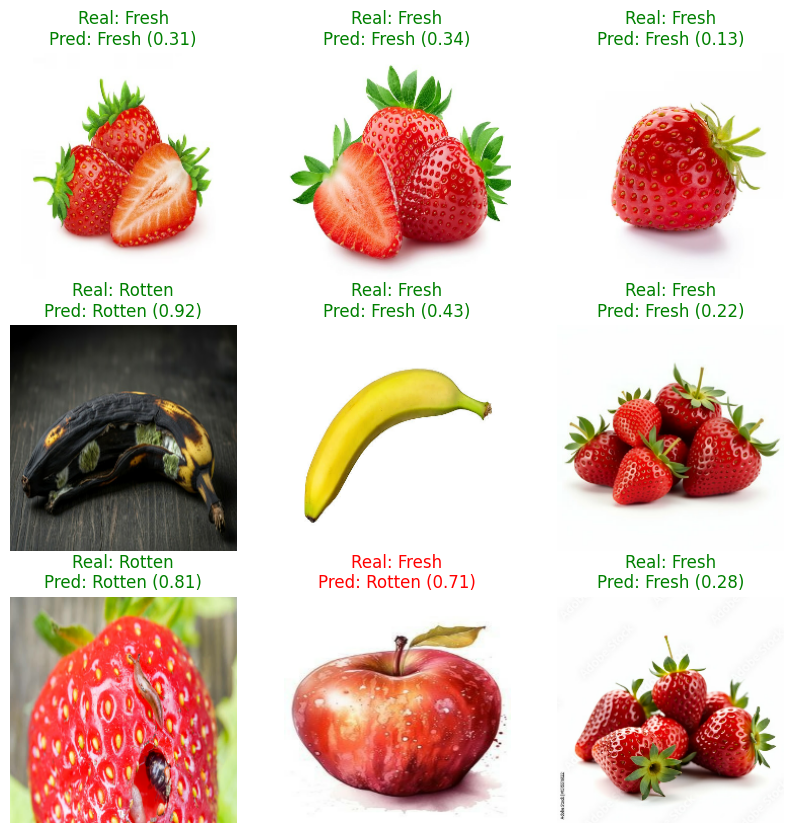

In [29]:
# Evaluate on Test Set
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: %{accuracy*100:.2f}")

# Visualizing Predictions
import matplotlib.pyplot as plt

# Get a batch from test set
image_batch, label_batch = next(iter(test_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = image_batch[i].numpy().astype("uint8")
    label = label_batch[i].numpy()
    
    # Prediction
    pred_prob = model.predict(tf.expand_dims(image_batch[i], 0), verbose=0)[0][0]
    pred_label = "Rotten" if pred_prob >= 0.5 else "Fresh"
    real_label = "Rotten" if label == 1 else "Fresh"
    
    color = "green" if pred_label == real_label else "red"
    
    plt.imshow(img)
    plt.title(f"Real: {real_label}\nPred: {pred_label} ({pred_prob:.2f})", color=color)
    plt.axis("off")

## 9. Performance Metrics & Analysis

Detailed analysis using Confusion Matrix and Loss/Accuracy curves.

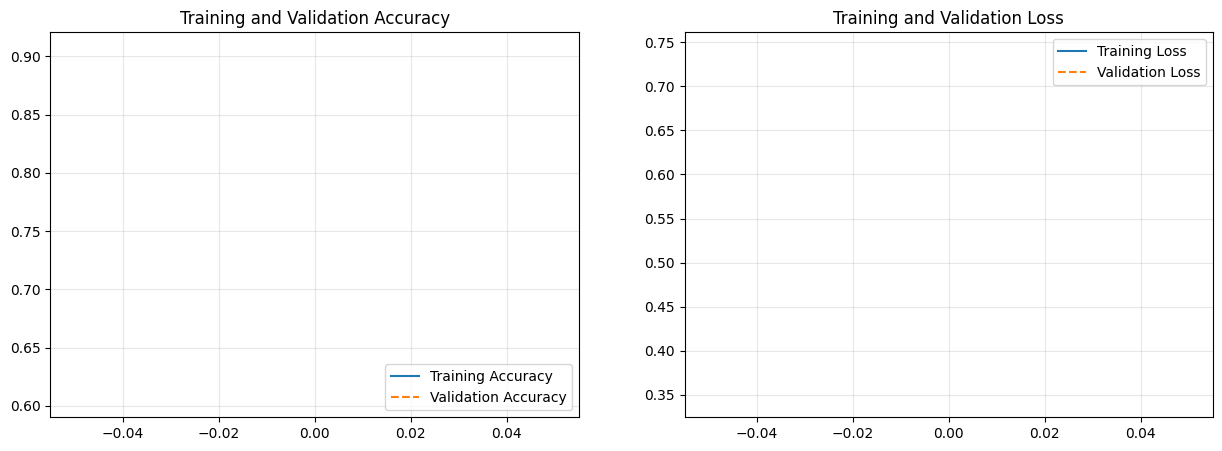

Generating predictions for Confusion Matrix...


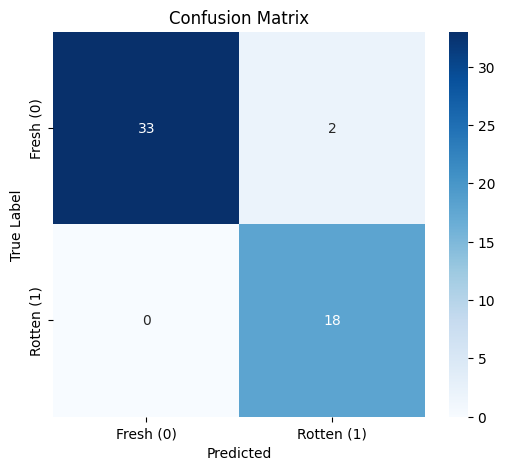


Classification Report:
              precision    recall  f1-score   support

       Fresh       1.00      0.94      0.97        35
      Rotten       0.90      1.00      0.95        18

    accuracy                           0.96        53
   macro avg       0.95      0.97      0.96        53
weighted avg       0.97      0.96      0.96        53



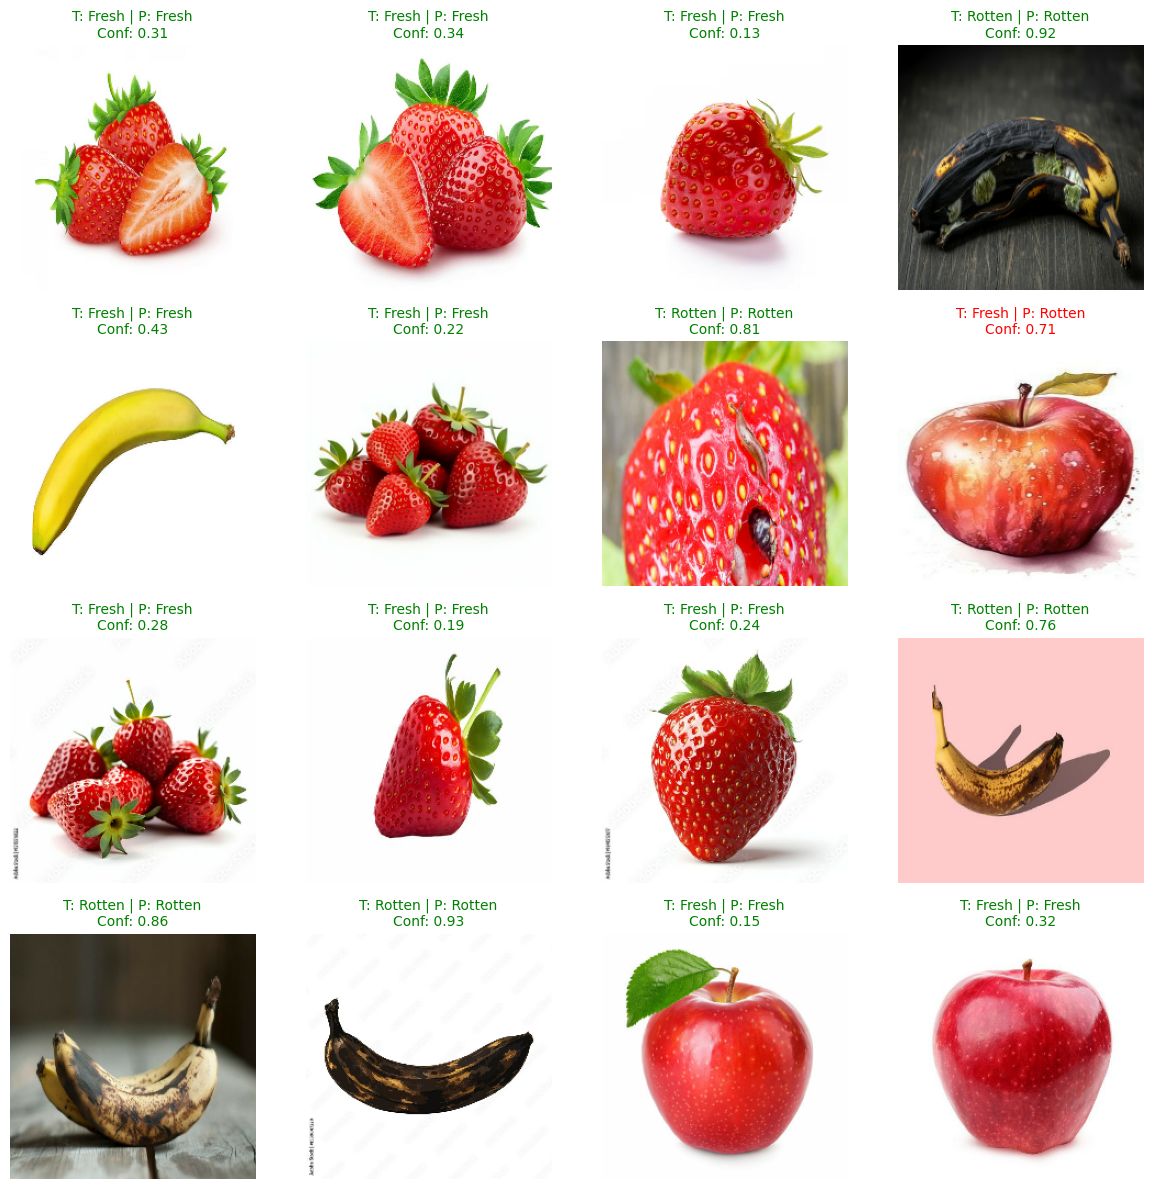

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. PLOTTING HISTORY
# -----------------------------------------------------------
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.grid(True, alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True, alpha=0.3)
    
    plt.show()

# Plotting the history of the last training phase
try:
    plot_history(history_fine) 
except NameError:
    plot_history(history)


# 2. CONFUSION MATRIX
# -----------------------------------------------------------
print("Generating predictions for Confusion Matrix...")

y_true = []
y_pred_probs = []

# Iterate over test set
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred_probs.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
# Threshold 0.5 for Binary Classification (0: Fresh, 1: Rotten)
y_pred = (y_pred_probs > 0.5).astype(int) 

# Plot Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fresh (0)', 'Rotten (1)'], 
            yticklabels=['Fresh (0)', 'Rotten (1)'])
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fresh', 'Rotten']))


# 3. VISUAL CHECK
# -----------------------------------------------------------
plt.figure(figsize=(12, 12))
image_batch, label_batch = next(iter(test_ds))

for i in range(16): # Show first 16 images
    ax = plt.subplot(4, 4, i + 1)
    img = image_batch[i].numpy().astype("uint8") 
    true_label_idx = label_batch[i].numpy()
    
    # Single prediction
    pred_prob = model.predict(tf.expand_dims(image_batch[i], 0), verbose=0)[0][0]
    pred_label_idx = 1 if pred_prob > 0.5 else 0
    
    label_names = {0: "Fresh", 1: "Rotten"}
    
    color = "green" if pred_label_idx == true_label_idx else "red"
    
    plt.imshow(img)
    plt.title(f"T: {label_names[true_label_idx]} | P: {label_names[pred_label_idx]}\nConf: {pred_prob:.2f}", 
              color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()